In [1]:
import os
gpu_num = 0 # Use "" to use the CPU
os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Colab does currently not support the latest version of ipython.
# Thus, the preview does not work in Colab. However, whenever possible we
# strongly recommend to use the scene preview mode.
try: # detect if the notebook runs in Colab
    import google.colab
    colab_compat = True # deactivate preview
except:
    colab_compat = False
resolution = [480,320] # increase for higher quality of renderings

# Allows to exit cell execution in Jupyter
class ExitCell(Exception):
    def _render_traceback_(self):
        pass

# Import Sionna
try:
    import sionna
except ImportError as e:
    # Install Sionna if package is not already installed
    import os
    os.system("pip install sionna")
    import sionna

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

tf.random.set_seed(1) # Set global random seed for reproducibility


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time

# Import Sionna RT components
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, Camera

# For link-level simulations
from sionna.channel import cir_to_ofdm_channel, subcarrier_frequencies, OFDMChannel, ApplyOFDMChannel, CIRDataset
from sionna.nr import PUSCHConfig, PUSCHTransmitter, PUSCHReceiver
from sionna.utils import compute_ber, ebnodb2no, PlotBER
from sionna.ofdm import KBestDetector, LinearDetector
from sionna.mimo import StreamManagement


Renderer(camera=PerspectiveCamera(aspect=1.31, children=(DirectionalLight(intensity=0.25, position=(0.0, 0.0, …

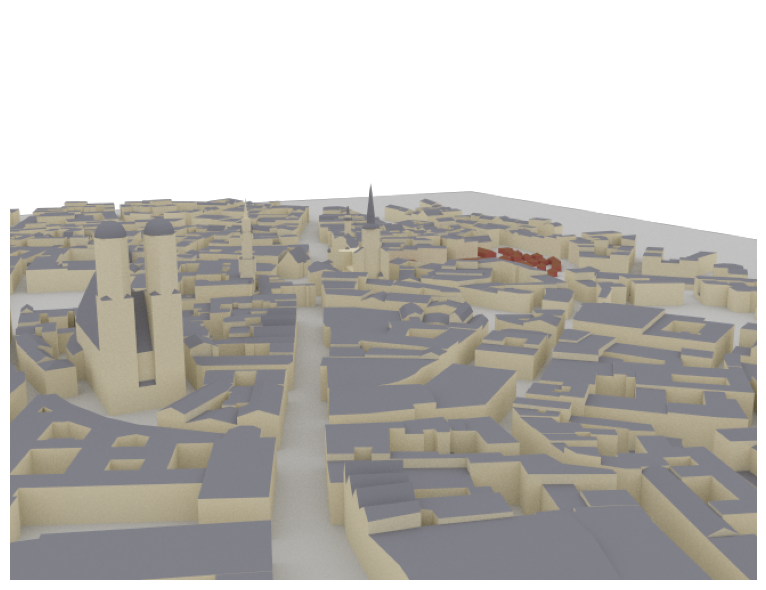

In [3]:
scene = load_scene(sionna.rt.scene.munich)
scene.render(camera="scene-cam-0")
scene.preview()

In [4]:
# Configure antenna array for all transmitters
scene.tx_array = PlanarArray(num_rows=8,
                          num_cols=2,
                          vertical_spacing=0.7,
                          horizontal_spacing=0.5,
                          pattern="tr38901",
                          polarization="VH")

# Configure antenna array for all receivers
scene.rx_array = PlanarArray(num_rows=1,
                          num_cols=1,
                          vertical_spacing=0.5,
                          horizontal_spacing=0.5,
                          pattern="dipole",
                          polarization="cross")

# Create transmitter
tx = Transmitter(name="tx",
              position=[8.5,21,27],
              orientation=[0,0,0])
scene.add(tx)

# Create a receiver
rx = Receiver(name="rx",
           position=[45,90,1.5],
           orientation=[0,0,0])
scene.add(rx)

# TX points towards RX
tx.look_at(rx)

print(scene.transmitters)
print(scene.receivers)


AttributeError: 'dict' object has no attribute 'numpy'

In [ ]:

scene.frequency = 2.14e9 # in Hz; implicitly updates RadioMaterials

scene.synthetic_array = True # If set to False, ray tracing will be done per antenna element (slower for large arrays)
# Select an example object from the scene
so = scene.get("Altes_Rathaus-itu_marble")

# Frequências que queres para imprimir informação do material radio(radio material information)
frequencies = [3.5e9, 2.14e9]

# Print name of assigned radio material for different frequenies
#for f in frequencies:: # Print for differrent frequencies
    #scene.frequency = f
    #print(f"\nRadioMaterial: {so.radio_material.name} @ {scene.frequency/1e9:.2f}GHz")
    #print("Conductivity:", so.radio_material.conductivity.numpy())
    #print("Relative permittivity:", so.radio_material.relative_permittivity.numpy())
    #print("Complex relative permittivity:", so.radio_material.complex_relative_permittivity.numpy())
    #print("Relative permeability:", so.radio_material.relative_permeability.numpy())
    #print("Scattering coefficient:", so.radio_material.scattering_coefficient.numpy())
    #print("XPD coefficient:", so.radio_material.xpd_coefficient.numpy())



with open("Altes_Rathaus-itu_marble.txt", "w") as file:
    # Iterate over the frequencies
    for f in frequencies:
        # Set the scene to the current frequency
        scene.frequency = f
        # Write radio material information to the file
        file.write(f"\nRadioMaterial: {so.radio_material.name} @ {scene.frequency/1e9:.2f}GHz\n")
        file.write("Conductivity: {}\n".format(so.radio_material.conductivity.numpy()))
        file.write("Relative permittivity: {}\n".format(so.radio_material.relative_permittivity.numpy()))
        file.write("Complex relative permittivity: {}\n".format(so.radio_material.complex_relative_permittivity.numpy()))
        file.write("Relative permeability: {}\n".format(so.radio_material.relative_permeability.numpy()))
        file.write("Scattering coefficient: {}\n".format(so.radio_material.scattering_coefficient.numpy()))
        file.write("XPD coefficient: {}\n".format(so.radio_material.xpd_coefficient.numpy()))
        
        print(f"\nRadioMaterial: {so.radio_material.name} @ {scene.frequency/1e9:.2f}GHz")
        print("Conductivity:", so.radio_material.conductivity.numpy())
        print("Relative permittivity:", so.radio_material.relative_permittivity.numpy())
        print("Complex relative permittivity:", so.radio_material.complex_relative_permittivity.numpy())
        print("Relative permeability:", so.radio_material.relative_permeability.numpy())
        print("Scattering coefficient:", so.radio_material.scattering_coefficient.numpy())
        print("XPD coefficient:", so.radio_material.xpd_coefficient.numpy())

# Print a message indicating that the information has been saved
print("Radio material information has been saved in 'Altes_Rathaus-itu_marble.txt'.")

In [ ]:
paths = scene.compute_paths() #Cria os caminhos do sinal
scene.render(camera="scene-cam-0")
scene.preview(paths=paths) #Mostra a cena 3D com os caminhos
#scene.render_to_file(camera="preview", filename="scene.png", paths=paths) # Cria uma imagem com os caminhos

In [ ]:
path_idx = 4
variavel_indefinida = 1
# Mostra a começa a transmissão do sinal(fonte) de todos os arrays.
# Coincide com a localização de todos os transmissores.
print("Source coordinates: ", paths.sources.numpy())
print("Transmitter coordinates: ", list(scene.transmitters.values())[0].position.numpy())
print("Coordenadas onde os caminhos são refletidos: ",  paths.vertices)
print("Coordenadas onde os caminhos são refletidos: ",  paths.vertices[0,0,0,1])
#print("Coordenadas onde os caminhos são refletidos: ",  paths.vertices.numpy()[variavel_indefinida,0,0,path_idx])

# Mostra as coordenadas dos pontos de receção de todos os arrays.
# Coincide com a localização de todos os recetores.
print("Target coordinates: ",paths.targets.numpy())
print("Receiver coordinates: ",list(scene.receivers.values())[0].position.numpy())
    
# Show the types of all paths:
# 0 - LoS, 1 - Reflected, 2 - Diffracted, 3 - Scattered
# Note that Diffraction and scattering are turned off by default.
print("Path types: ", paths.types.numpy())

In [ ]:
# Abra o arquivo para escrita
with open("coordinates_info.txt", "w") as f:
       # Show the coordinates of the starting points of all rays.
    # These coincide with the location of the transmitters.
    print("Source coordinates: ", paths.sources.numpy(), file=f)
    print("Transmitter coordinates: ", list(scene.transmitters.values())[0].position.numpy(), file=f)
    
    # Show the coordinates of the endpoints of all rays.
    # These coincide with the location of the receivers.
    print("Target coordinates: ", paths.targets.numpy(), file=f)
    print("Receiver coordinates: ", list(scene.receivers.values())[0].position.numpy(), file=f)

    # Show the types of all paths:
    # 0 - LoS, 1 - Reflected, 2 - Diffracted, 3 - Scattered
    # Note that Diffraction and scattering are turned off by default.
    print("Path types: ", paths.types.numpy(), file=f)

print("As informações foram salvas em 'coordinates_info.txt'.")


In [ ]:


print(f"\n--- Detailed results for path {path_idx} ---\n")
print(f"Channel coefficient: {paths.a[0,0,0,0,0,path_idx, 0].numpy()}\n")
print(f"Propagation delay: {paths.tau[0,0,0,path_idx].numpy()*1e6:.5f} us\n")
print(f"Zenith angle of departure: {paths.theta_t[0,0,0,path_idx]:.4f} rad\n")
print(f"Azimuth angle of departure: {paths.phi_t[0,0,0,path_idx]:.4f} rad\n")
print(f"Zenith angle of arrival: {paths.theta_r[0,0,0,path_idx]:.4f} rad\n")
print(f"Azimuth angle of arrival: {paths.phi_r[0,0,0,path_idx]:.4f} rad\n")




In [ ]:
scene.frequency = 2.14e9 # in Hz; implicitly updates RadioMaterials

scene.synthetic_array = True # If set to False, ray tracing will be done per antenna element (slower for large arrays)

In [ ]:


# Exemplo de objeto retirado da cena
so = scene.get("Altes_Rathaus-itu_marble")

# Gama de Frequências que queres para imprimir informação do material radio(radio material information)
frequencies = [3.5e9, 2.14e9]


# Open the file for writing
with open("Altes_Rathaus-itu_marble.txt", "w") as file:
    # Iterate over the frequencies
    for f in frequencies:
        # Set the scene to the current frequency
        scene.frequency = f
        
        # Write radio material information to the file
        file.write(f"\nRadioMaterial: {so.radio_material.name} @ {scene.frequency/1e9:.2f}GHz\n")
        file.write("Conductivity: {}\n".format(so.radio_material.conductivity.numpy()))
        file.write("Relative permittivity: {}\n".format(so.radio_material.relative_permittivity.numpy()))
        file.write("Complex relative permittivity: {}\n".format(so.radio_material.complex_relative_permittivity.numpy()))
        file.write("Relative permeability: {}\n".format(so.radio_material.relative_permeability.numpy()))
        file.write("Scattering coefficient: {}\n".format(so.radio_material.scattering_coefficient.numpy()))
        file.write("XPD coefficient: {}\n".format(so.radio_material.xpd_coefficient.numpy()))

# Print a message indicating that the information has been saved
print("Radio material information has been saved in 'Altes_Rathaus-itu_marble.txt'.")

